In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plot appearance
sns.set_style("whitegrid")



In [26]:
demo_clean = pd.read_csv("/Users/akashkumarsamantray/Desktop/demo_clean.csv")
web_combined = pd.read_csv("/Users/akashkumarsamantray/Desktop/web_combined.csv")
experiment = pd.read_csv("/Users/akashkumarsamantray/Desktop/experiment.csv")

print("demo_clean",demo_clean)
print("web_combined ",web_combined)
print("experiment",experiment)

demo_clean        client_id  client_tenure_years  client_tenure_months  client_age  \
0         836976                  6.0                  73.0        60.5   
1        2304905                  7.0                  94.0        58.0   
2        1439522                  5.0                  64.0        32.0   
3        1562045                 16.0                 198.0        49.0   
4        5126305                 12.0                 145.0        33.0   
...          ...                  ...                   ...         ...   
70604    7993686                  4.0                  56.0        38.5   
70605    8981690                 12.0                 148.0        31.0   
70606     333913                 16.0                 198.0        61.5   
70607    1573142                 21.0                 255.0        68.0   
70608    5602139                 21.0                 254.0        59.5   

      gender  num_accts     balance  calls_last_6_months  logons_6_mnth  
0          U  

In [30]:
## Important Columns

web_combine.columns


,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [31]:
## Converted timestamp column

web_combined['date_time'] = pd.to_datetime(web_combined['date_time'])

web_combined['date_time']

0        2017-04-12 20:19:36
1        2017-04-12 20:19:45
2        2017-04-12 20:20:31
3        2017-04-12 20:22:05
4        2017-04-12 20:23:09
                 ...        
744636   2017-06-01 22:40:08
744637   2017-06-01 22:41:28
744638   2017-06-01 22:41:47
744639   2017-06-01 22:44:58
744640   2017-06-01 22:48:39
Name: date_time, Length: 744641, dtype: datetime64[ns]

In [12]:
## Sorting Data, ensuring steps are in correct order

web_combined = web_combined.sort_values(
    by=['client_id', 'date_time']
)
web_combined

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
...,...,...,...,...,...
744636,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08
744637,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28
744638,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47
744639,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58


In [32]:
## Calculate next time stamp to get next step timestamp

web_combined['next_time'] = web_combined.groupby('client_id')['date_time'].shift(-1)

web_combined

,client_id,visitor_id,visit_id,process_step,date_time,Variation,next_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,NaN,2017-04-12 20:19:45
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,NaN,2017-04-12 20:20:31
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,NaN,2017-04-12 20:22:05
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,NaN,2017-04-12 20:23:09
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,NaN,NaT
...,...,...,...,...,...,...,...
744636,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08,NaN,2017-06-01 22:41:28
744637,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28,NaN,2017-06-01 22:41:47
744638,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47,NaN,2017-06-01 22:44:58
744639,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58,NaN,2017-06-01 22:48:39


In [33]:
## Calculating time spent(every row will contain time spent on that step)

web_combined['time_spent_sec'] = (
    web_combined['next_time'] - web_combined['date_time']
).dt.total_seconds()

web_combined['time_spent_sec']

0           9.0
1          46.0
2          94.0
3          64.0
4           NaN
          ...  
744636     80.0
744637     19.0
744638    191.0
744639    221.0
744640      NaN
Name: time_spent_sec, Length: 744641, dtype: float64

In [34]:
## Removing Odd values
## negative duration
## inactive sessions above 30 mins

web_combined = web_combined[
    (web_combined['time_spent_sec'] >= 0) &
    (web_combined['time_spent_sec'] <= 1800)
]

web_combined

,client_id,visitor_id,visit_id,process_step,date_time,Variation,next_time,time_spent_sec
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,NaN,2017-04-12 20:19:45,9.0
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,NaN,2017-04-12 20:20:31,46.0
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,NaN,2017-04-12 20:22:05,94.0
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,NaN,2017-04-12 20:23:09,64.0
5,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55,NaN,2017-06-01 07:42:43,948.0
...,...,...,...,...,...,...,...,...
744635,9999875,738878760_1556639849,931268933_219402947_599432,start,2017-06-01 22:40:01,NaN,2017-06-01 22:40:08,7.0
744636,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08,NaN,2017-06-01 22:41:28,80.0
744637,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28,NaN,2017-06-01 22:41:47,19.0
744638,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47,NaN,2017-06-01 22:44:58,191.0


In [44]:
## KPI Calculation

## Average time per step: mean

step_kpi = web_combined.groupby('process_step')['time_spent_sec'].mean()

step_kpi


process_step
confirm    229.012694
start       57.365670
step_1      58.988127
step_2      91.674965
step_3     128.979647
Name: time_spent_sec, dtype: float64

In [51]:
## Average time per step: Median

step_median = web_combined.groupby('process_step')['time_spent_sec'].median()
step_median

process_step
confirm    75.0
start      15.0
step_1     26.0
step_2     63.0
step_3     61.0
Name: time_spent_sec, dtype: float64

In [52]:
## Comparing New VS Old design
## IMPORTANT for redesign analysis
## can compare control vs step
## can compare step by step


variat_kpi = web_combined.groupby(
    ['Variation', 'process_step']
)['time_spent_sec'].mean().reset_index()

variat_kpi

,Variation,process_step,time_spent_sec
0,Control,confirm,146.715183
1,Control,start,61.983197
2,Control,step_1,48.039988
3,Control,step_2,90.544220
4,Control,step_3,133.492827
5,Test,confirm,218.033498
6,Test,start,56.795166
7,Test,step_1,58.891680
8,Test,step_2,88.418755
9,Test,step_3,125.065532


In [50]:
web_combined

,client_id,visitor_id,visit_id,process_step,date_time,Variation_x,next_time,time_spent_sec,Variation_y,Variation
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,NaN,2017-04-12 20:19:45,9.0,NaN,NaN
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,NaN,2017-04-12 20:20:31,46.0,NaN,NaN
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,NaN,2017-04-12 20:22:05,94.0,NaN,NaN
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,NaN,2017-04-12 20:23:09,64.0,NaN,NaN
4,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55,NaN,2017-06-01 07:42:43,948.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
586719,9999875,738878760_1556639849,931268933_219402947_599432,start,2017-06-01 22:40:01,NaN,2017-06-01 22:40:08,7.0,NaN,NaN
586720,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08,NaN,2017-06-01 22:41:28,80.0,NaN,NaN
586721,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28,NaN,2017-06-01 22:41:47,19.0,NaN,NaN
586722,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47,NaN,2017-06-01 22:44:58,191.0,NaN,NaN


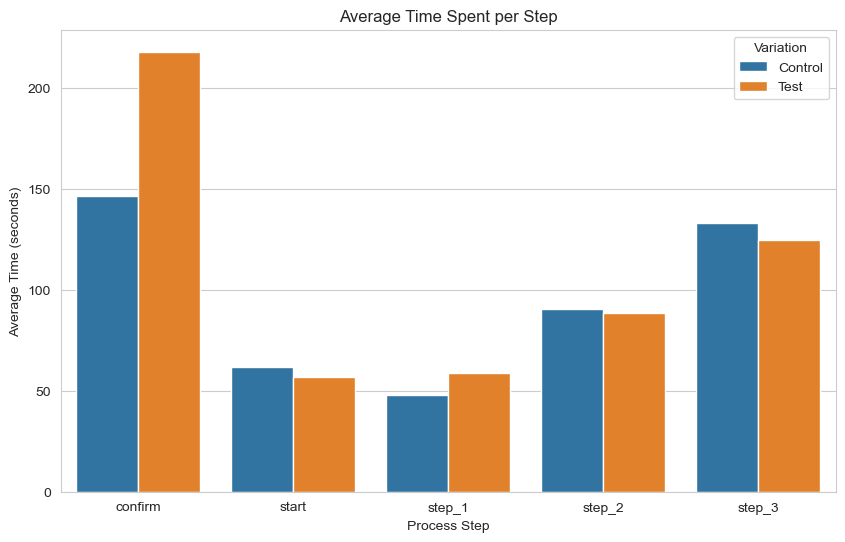

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.barplot(
    data=variat_kpi,
    x='process_step',
    y='time_spent_sec',
    hue='Variation'
)

plt.title('Average Time Spent per Step')
plt.ylabel('Average Time (seconds)')
plt.xlabel('Process Step')

plt.show()